# Notebook 4: Theory — The Four Explanatory Item Response Models

**Reference:** Wilson, M., De Boeck, P., & Carstensen, C. H. (2008). *Chapter 5: Explanatory Item Response Models: A Brief Introduction.*

This notebook provides the mathematical foundation for the four models we will fit in later notebooks. All models are special cases of **Generalized Linear Mixed Models (GLMMs)** with a **logit link** and **Bernoulli** random component.

---

## 1. The Big Picture: Measurement vs. Explanation

In standard IRT, every item and every person gets its own parameter. This is the **measurement** (or **descriptive**) approach — we describe *that* items and persons differ, but not *why*.

The **explanatory** approach replaces those individual parameters with functions of observable **properties**:

- **Person properties** (gender, school program, SES) explain why some students do better.
- **Item properties** (topic area, modeling type) explain why some items are harder.

| | Item indicators (descriptive) | Item properties (explanatory) |
|---|---|---|
| **Person indicators (descriptive)** | Rasch Model | LLTM |
| **Person properties (explanatory)** | Latent Regression Rasch | Latent Regression LLTM |

## 2. The GLMM Framework

All four models share three components:

### (a) Random Component
The observed response $Y_{pi}$ (person $p$, item $i$) follows a Bernoulli distribution:

$$Y_{pi} \sim \text{Bernoulli}(\pi_{pi})$$

where $\pi_{pi} = P(Y_{pi}=1 \mid \theta_p)$ is the probability of a correct response.

### (b) Link Function
The **logit link** connects $\pi_{pi}$ to a linear predictor $\eta_{pi}$:

$$\text{logit}(\pi_{pi}) = \ln\frac{\pi_{pi}}{1 - \pi_{pi}} = \eta_{pi}$$

Equivalently:

$$\pi_{pi} = \frac{\exp(\eta_{pi})}{1 + \exp(\eta_{pi})} = \frac{1}{1 + \exp(-\eta_{pi})}$$

### (c) Linear Component
This is where the four models differ. In the most general form:

$$\eta_{pi} = \sum_k \beta_k X_{ik} + \sum_j \vartheta_j Z_{pj} + \theta_p$$

where the $X_{ik}$ are item predictors, $Z_{pj}$ are person predictors, $\beta_k$ and $\vartheta_j$ are fixed effects, and $\theta_p$ is a random person effect.

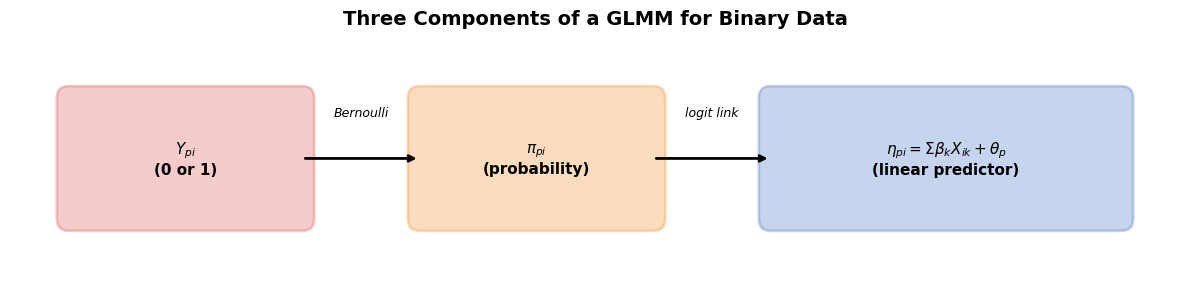

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Visualize the GLMM structure ──
fig, ax = plt.subplots(figsize=(12, 3))
ax.set_xlim(0, 10); ax.set_ylim(0, 2)
ax.axis('off')

boxes = [
    (0.5, 0.5, 2.0, 1.0, '$Y_{pi}$\n(0 or 1)', '#E15759'),
    (3.5, 0.5, 2.0, 1.0, '$\\pi_{pi}$\n(probability)', '#F28E2B'),
    (6.5, 0.5, 3.0, 1.0, '$\\eta_{pi} = \\Sigma \\beta_k X_{ik} + \\theta_p$\n(linear predictor)', '#4472C4'),
]
for x, y, w, h, label, color in boxes:
    rect = mpatches.FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.1',
                                    facecolor=color, alpha=0.3, edgecolor=color, linewidth=2)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, label, ha='center', va='center', fontsize=11, fontweight='bold')

# Arrows
for x1, x2, label in [(2.5, 3.5, 'Bernoulli'), (5.5, 6.5, 'logit link')]:
    ax.annotate('', xy=(x2, 1.0), xytext=(x1, 1.0),
                arrowprops=dict(arrowstyle='->', color='black', lw=2))
    ax.text((x1+x2)/2, 1.35, label, ha='center', fontsize=9, style='italic')

ax.set_title('Three Components of a GLMM for Binary Data', fontweight='bold', fontsize=14, pad=10)
plt.tight_layout()
plt.show()

## 3. Model 1: The Rasch Model (Doubly Descriptive)

$$\eta_{pi} = \theta_p - \beta_i$$

- $\theta_p \sim N(0, \sigma^2)$ — random person ability
- $\beta_i$ — fixed item difficulty (one per item)
- Convention: the minus sign means higher $\beta_i$ = harder item

**Interpretation:** The probability of success is a function of the *difference* between person ability and item difficulty:

$$\pi_{pi} = \frac{\exp(\theta_p - \beta_i)}{1 + \exp(\theta_p - \beta_i)}$$

When $\theta_p = \beta_i$, the probability is exactly 0.50.

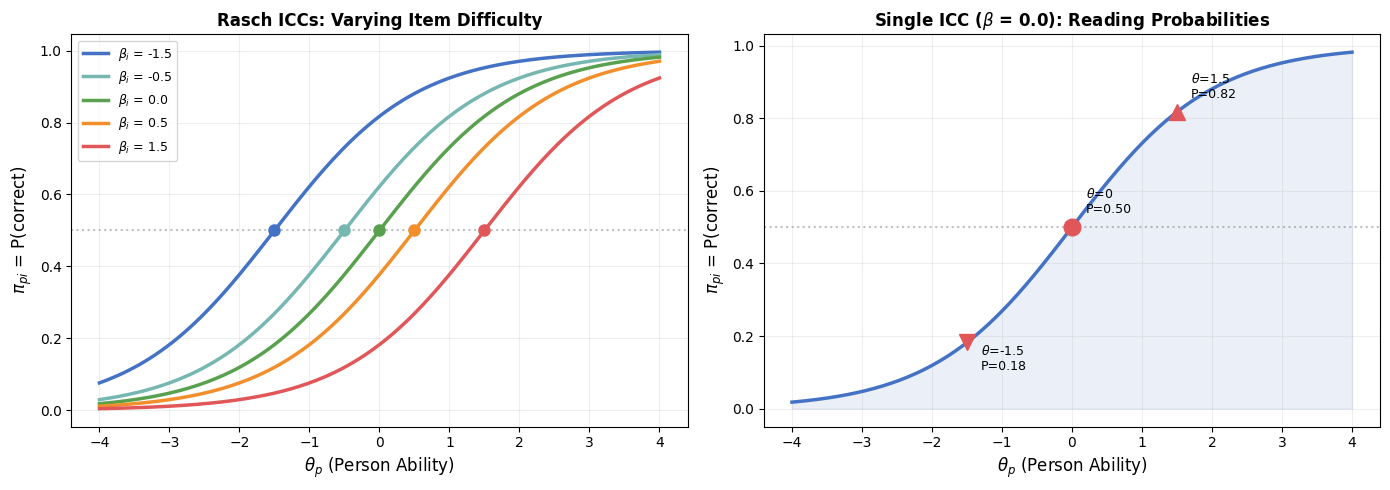

In [2]:
# ── Item Characteristic Curves for the Rasch model ──
def logistic(x):
    return 1 / (1 + np.exp(-x))

theta = np.linspace(-4, 4, 200)
betas = [-1.5, -0.5, 0.0, 0.5, 1.5]
colors = ['#4472C4', '#76B7B2', '#59A14F', '#F28E2B', '#E15759']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) ICCs for different item difficulties
ax = axes[0]
for beta, color in zip(betas, colors):
    p = logistic(theta - beta)
    ax.plot(theta, p, color=color, lw=2.5, label=f'$\\beta_i$ = {beta}')
    ax.plot(beta, 0.5, 'o', color=color, markersize=8, zorder=5)

ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('$\\theta_p$ (Person Ability)', fontsize=12)
ax.set_ylabel('$\\pi_{pi}$ = P(correct)', fontsize=12)
ax.set_title('Rasch ICCs: Varying Item Difficulty', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.2)

# (b) Odds ratio interpretation
ax = axes[1]
beta_fixed = 0.0
p_curve = logistic(theta - beta_fixed)
ax.plot(theta, p_curve, color='#4472C4', lw=2.5)
ax.fill_between(theta, 0, p_curve, alpha=0.1, color='#4472C4')

# Mark specific points
for t, style in [(-1.5, 'v'), (0, 'o'), (1.5, '^')]:
    p_val = logistic(t - beta_fixed)
    ax.plot(t, p_val, style, color='#E15759', markersize=12, zorder=5)
    ax.annotate(f'$\\theta$={t}\nP={p_val:.2f}', (t, p_val),
                xytext=(10, -20 if t < 0 else 10), textcoords='offset points', fontsize=9)

ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('$\\theta_p$ (Person Ability)', fontsize=12)
ax.set_ylabel('$\\pi_{pi}$ = P(correct)', fontsize=12)
ax.set_title(f'Single ICC ($\\beta$ = {beta_fixed}): Reading Probabilities', fontweight='bold')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

## 4. Model 2: Latent Regression Rasch (Person Explanatory)

$$\eta_{pi} = \sum_{j=1}^{J} \vartheta_j Z_{pj} + \theta_p - \beta_i$$

- $Z_{pj}$ = person $p$'s value on property $j$ (e.g., gender, program, SES)
- $\vartheta_j$ = fixed effect of person property $j$
- $\theta_p \sim N(0, \sigma_\varepsilon^2)$ = **residual** person effect (after properties are accounted for)

The person ability is **decomposed** into an explained part and a residual:

$$\underbrace{\theta_p^{\text{total}}}_{\text{original Rasch}} = \underbrace{\sum_j \vartheta_j Z_{pj}}_{\text{explained by properties}} + \underbrace{\theta_p}_{\text{residual}}$$

**In our example:** $J = 7$ predictors — program dummies (3), gender×program (3), SES (1).

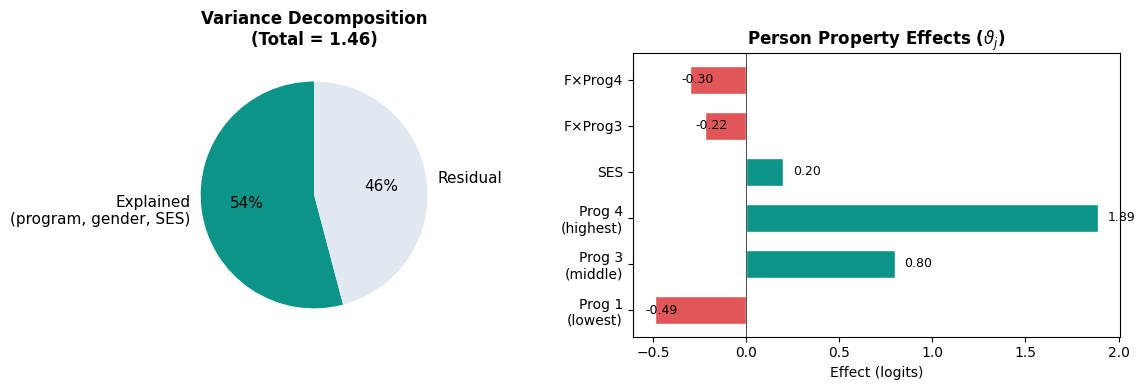

In [3]:
# ── Visualize variance decomposition ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart of variance decomposition
ax = axes[0]
explained = 0.79
residual = 0.67
total = explained + residual
ax.pie([explained, residual], labels=['Explained\n(program, gender, SES)', 'Residual'],
       colors=['#0D9488', '#E2E8F0'], autopct='%1.0f%%', startangle=90,
       textprops={'fontsize': 11})
ax.set_title(f'Variance Decomposition\n(Total = {total:.2f})', fontweight='bold')

# Effect sizes
ax = axes[1]
effects = {'Prog 1\n(lowest)': -0.49, 'Prog 3\n(middle)': 0.80, 'Prog 4\n(highest)': 1.89,
           'SES': 0.20, 'F×Prog3': -0.22, 'F×Prog4': -0.30}
names = list(effects.keys())
vals = list(effects.values())
color_bars = ['#E15759' if v < 0 else '#0D9488' for v in vals]
ax.barh(names, vals, color=color_bars, edgecolor='white', height=0.6)
ax.axvline(0, color='black', lw=0.5)
ax.set_xlabel('Effect (logits)')
ax.set_title('Person Property Effects ($\\vartheta_j$)', fontweight='bold')
for i, v in enumerate(vals):
    ax.text(v + 0.05 * np.sign(v), i, f'{v:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 5. Model 3: LLTM (Item Explanatory)

$$\eta_{pi} = \theta_p - \sum_{k=0}^{K} \beta_k X_{ik}$$

- $X_{ik}$ = value of item $i$ on item property $k$ (topic area, modeling type)
- $\beta_k$ = fixed effect of item property $k$
- Individual item parameters $\beta_i$ are **replaced** by $\beta_i' = \sum_k \beta_k X_{ik}$

**In our example:** 9 parameters (one per topic×modeling cell) replace 18 individual item difficulties.

The key test: does $\beta_i' \approx \beta_i$? In the chapter, the correlation is $r = 0.98$.

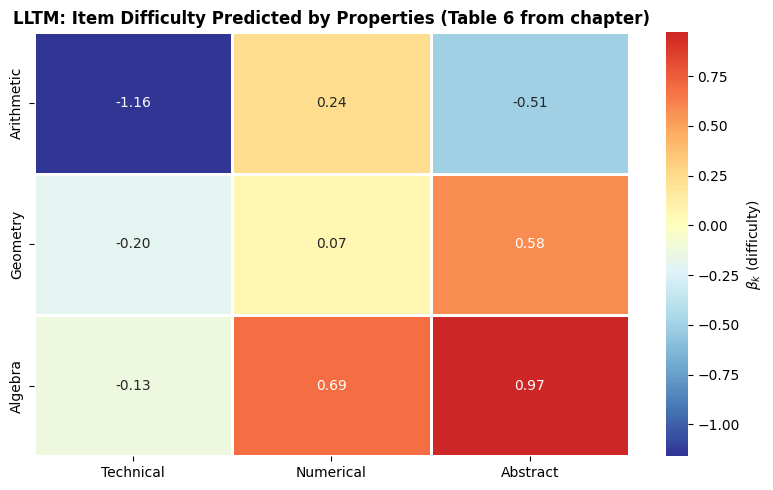

Each cell value is a β_k — the predicted difficulty for items in that cell.
Two items share each cell value (2 replicates per design cell).
Blue = easy, Red = hard.


In [4]:
# ── Visualize the LLTM item property matrix ──
topic_areas = ['Arithmetic', 'Geometry', 'Algebra']
modeling_types = ['Technical', 'Numerical', 'Abstract']

fig, ax = plt.subplots(figsize=(8, 5))

# Show how 18 items map to 9 cells
cell_betas = np.array([
    [-1.16, 0.24, -0.51],   # Arithmetic
    [-0.20, 0.07,  0.58],   # Geometry
    [-0.13, 0.69,  0.97],   # Algebra
])

import seaborn as sns
sns.heatmap(cell_betas, annot=True, fmt='.2f', cmap='RdYlBu_r', center=0,
            xticklabels=modeling_types, yticklabels=topic_areas,
            linewidths=2, linecolor='white', ax=ax,
            cbar_kws={'label': '$\\beta_k$ (difficulty)'})
ax.set_title('LLTM: Item Difficulty Predicted by Properties (Table 6 from chapter)',
             fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

print('Each cell value is a β_k — the predicted difficulty for items in that cell.')
print('Two items share each cell value (2 replicates per design cell).')
print('Blue = easy, Red = hard.')

## 6. Model 4: Latent Regression LLTM (Doubly Explanatory)

$$\eta_{pi} = \sum_{j=1}^{J} \vartheta_j Z_{pj} + \theta_p - \sum_{k=0}^{K} \beta_k X_{ik}$$

This combines Models 2 and 3:
- Person side is **explained** by person properties ($Z$) + residual ($\theta_p$)
- Item side is **explained** by item properties ($X$)

The previous three models are all special cases:

| To get... | Remove... |
|---|---|
| LLTM | person properties ($Z$'s) |
| Latent Regression Rasch | item properties (use item indicators instead) |
| Rasch | both |

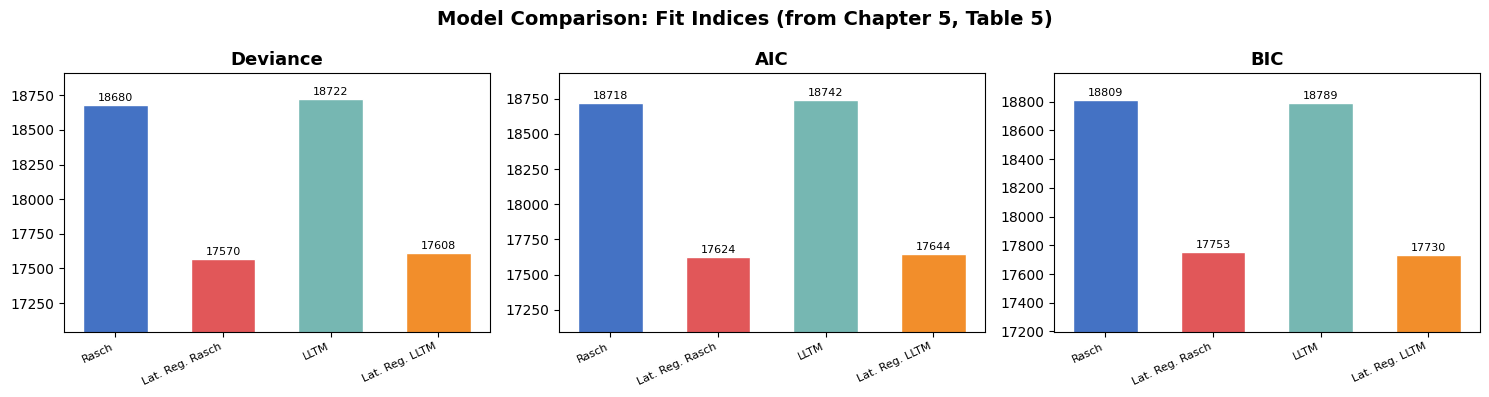

Lower values = better fit.
The Latent Regression models (with person properties) have much better fit.
BIC penalizes extra parameters more heavily than AIC.


In [5]:
# ── Model comparison: fit indices from the chapter ──
models_ch = ['Rasch', 'Lat. Reg. Rasch', 'LLTM', 'Lat. Reg. LLTM']
deviance_ch = [18680.3, 17570.1, 18721.5, 17608.2]
aic_ch = [18718.3, 17624.1, 18741.5, 17644.2]
bic_ch = [18809.1, 17753.2, 18789.3, 17730.3]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['#4472C4', '#E15759', '#76B7B2', '#F28E2B']

for ax, metric, values in zip(axes, ['Deviance', 'AIC', 'BIC'],
                               [deviance_ch, aic_ch, bic_ch]):
    x = np.arange(4)
    bars = ax.bar(x, values, color=colors, edgecolor='white', width=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(models_ch, rotation=25, ha='right', fontsize=8)
    ax.set_title(metric, fontweight='bold', fontsize=13)
    ax.set_ylim(min(values)*0.97, max(values)*1.01)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                f'{val:.0f}', ha='center', fontsize=8)

plt.suptitle('Model Comparison: Fit Indices (from Chapter 5, Table 5)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print('Lower values = better fit.')
print('The Latent Regression models (with person properties) have much better fit.')
print('BIC penalizes extra parameters more heavily than AIC.')

## 7. Summary Table

| Model | Equation | Person side | Item side | #Params (example) |
|-------|----------|-------------|-----------|---|
| Rasch | $\eta = \theta_p - \beta_i$ | descriptive | descriptive | 19 (18 items + 1 variance) |
| Lat. Reg. Rasch | $\eta = \Sigma\vartheta_j Z_{pj} + \theta_p - \beta_i$ | explanatory | descriptive | 26 (18 + 7 + 1) |
| LLTM | $\eta = \theta_p - \Sigma\beta_k X_{ik}$ | descriptive | explanatory | 10 (9 + 1) |
| Lat. Reg. LLTM | $\eta = \Sigma\vartheta_j Z_{pj} + \theta_p - \Sigma\beta_k X_{ik}$ | explanatory | explanatory | 17 (9 + 7 + 1) |

### Key insight

Moving from descriptive to explanatory gives us **understanding** at the cost of **assumptions**. The LLTM assumes item properties fully explain difficulties — a strong assumption tested by comparing with the Rasch model.

---

**Next:** Proceed to **NB5** to generate the simulated data using these models, then **NB6** to fit them with MML.